# Transformer models

The goal of this notebook is to train a transformer model to predict if a news if real or fake based on the title.

In this notebook, the **distilbert-base-uncased** model will be used.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = '/content/drive/MyDrive/nlp_project'
os.makedirs(project_path, exist_ok=True)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, f1_score, recall_score
from sklearn.model_selection import train_test_split

In [ ]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline

# Load the data

In [ ]:
## Read Training Data
df_train = pd.read_csv(f"{project_path}/training_data.csv", sep="\t", header=None, names=["label", "text"])

In [ ]:
## Read Testing Data
df_test = pd.read_csv(f"{project_path}/testing_data.csv", sep="\t", header=None, names=["label", "text"])

In [ ]:
df_train.head()

,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


# Trainer classs for distilbert-base-uncased

In [ ]:
X = df_train['text']
y = df_train['label']

from datasets.utils import stratify

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [ ]:
dataset = DatasetDict({ "train": Dataset.from_dict({ "text": X_train.tolist(),
                                                    "label": y_train.tolist(), }),
                        "test": Dataset.from_dict({ "text": X_test.tolist(),
                                                   "label": y_test.tolist(), }),
                        })
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 27321
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 6831
    })
})

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_dataset(dataset):
    return tokenizer(dataset["text"])
dataset = dataset.map(tokenize_dataset, batched=True)

Map:   0%|          | 0/27321 [00:00<?, ? examples/s]

Map:   0%|          | 0/6831 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
training_args = TrainingArguments(
    output_dir=(f"{project_path}/distilbert-base-uncased"),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    push_to_hub=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.106982,0.058034
2,0.025860,0.069495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=6832, training_loss=0.08604731967354268, metrics={'train_runtime': 244.3256, 'train_samples_per_second': 223.644, 'train_steps_per_second': 27.963, 'total_flos': 386207148429240.0, 'train_loss': 0.08604731967354268, 'epoch': 2.0})

In [ ]:
trainer.save_model(f"{project_path}/distilbert-base-uncased")
tokenizer.save_pretrained(f"{project_path}/distilbert-base-uncased")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/nlp_project/distilbert-base-uncased/tokenizer_config.json',
 '/content/drive/MyDrive/nlp_project/distilbert-base-uncased/tokenizer.json')

In [ ]:
predictions = trainer.predict(dataset['test'])
preds = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids

In [ ]:
print("Trainer Class distilbert-base-uncased")
print("Accuracy:", accuracy_score(true_labels, preds))
print(classification_report(true_labels, preds))
print(confusion_matrix(true_labels, preds))

Trainer Class distilbert-base-uncased
Accuracy: 0.9844825062216367
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3515
           1       0.99      0.98      0.98      3316

    accuracy                           0.98      6831
   macro avg       0.98      0.98      0.98      6831
weighted avg       0.98      0.98      0.98      6831

[[3474   41]
 [  65 3251]]


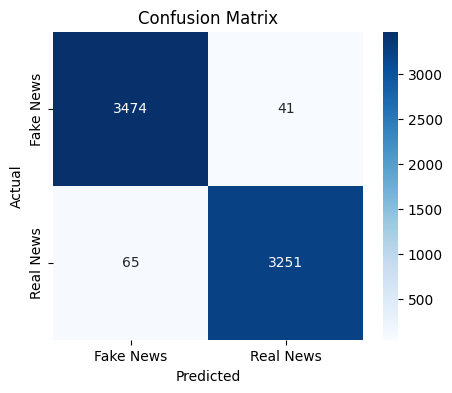

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake News", "Real News"], yticklabels=["Fake News", "Real News"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The results show that the trainer class allowed the distilbert-base-uncased model to have an excelent performance, with an accuracy of 0.984, with high precision and recall for both classifications.

# Predict the testing dataset

In [ ]:
df_test.head()

,label,text
0,2,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...


In [ ]:
text = df_test['text'].tolist()

In [ ]:
from transformers import pipeline

classifier = pipeline("text-classification", model=(f"{project_path}/distilbert-base-uncased/model"))
prediction_results = classifier(text)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
prediction_results

[{'label': 'LABEL_0', 'score': 0.9999508857727051},
 {'label': 'LABEL_0', 'score': 0.9999786615371704},
 {'label': 'LABEL_1', 'score': 0.9999909400939941},
 {'label': 'LABEL_0', 'score': 0.9998311996459961},
 {'label': 'LABEL_1', 'score': 0.9999909400939941},
 {'label': 'LABEL_0', 'score': 0.9999933242797852},
 {'label': 'LABEL_1', 'score': 0.9999911785125732},
 {'label': 'LABEL_0', 'score': 0.9999911785125732},
 {'label': 'LABEL_1', 'score': 0.9999885559082031},
 {'label': 'LABEL_1', 'score': 0.9999903440475464},
 {'label': 'LABEL_1', 'score': 0.999988317489624},
 {'label': 'LABEL_1', 'score': 0.9999852180480957},
 {'label': 'LABEL_0', 'score': 0.9999690055847168},
 {'label': 'LABEL_0', 'score': 0.999993085861206},
 {'label': 'LABEL_0', 'score': 0.9906845092773438},
 {'label': 'LABEL_0', 'score': 0.9999910593032837},
 {'label': 'LABEL_0', 'score': 0.9999923706054688},
 {'label': 'LABEL_0', 'score': 0.9999818801879883},
 {'label': 'LABEL_1', 'score': 0.9999897480010986},
 {'label': 'LA

In [ ]:
df_test['predicted_label'] = [r['label'] for r in prediction_results]

In [ ]:
df_test['confidence'] = [r['score'] for r in prediction_results]

In [ ]:
df_test.head()

,label,text,predicted_label,confidence
0,2,copycat muslim terrorist arrested with assault...,LABEL_0,0.999951
1,2,wow! chicago protester caught on camera admits...,LABEL_0,0.999979
2,2,germany's fdp look to fill schaeuble's big shoes,LABEL_1,0.999991
3,2,mi school sends welcome back packet warning ki...,LABEL_0,0.999831
4,2,u.n. seeks 'massive' aid boost amid rohingya '...,LABEL_1,0.999991


In [ ]:
df_test.to_csv(f"{project_path}/testing_data_predictions.csv")

# Using Hugging Face pipeline

In [ ]:
pipeline_classification = pipeline("text-classification", model="distilbert-base-uncased")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
pipeline_predictions = pipeline_classification(list(dataset["test"]["text"]))
pipeline_true_labels = list(dataset["test"]["label"])

In [ ]:
label_map = {
    "LABEL_0": 0,
    "LABEL_1": 1
}

pipeline_pred_ids = [label_map[pred["label"]] for pred in pipeline_predictions]
pipeline_true_labels = list(dataset["test"]["label"])

print("Pipeline distilbert-base-uncased")
print("Accuracy:", accuracy_score(pipeline_true_labels, pipeline_pred_ids))
print(classification_report(pipeline_true_labels, pipeline_pred_ids))
print(confusion_matrix(pipeline_true_labels, pipeline_pred_ids))

Pipeline distilbert-base-uncased
Accuracy: 0.47269799443712485
              precision    recall  f1-score   support

           0       0.46      0.13      0.20      3515
           1       0.48      0.84      0.61      3316

    accuracy                           0.47      6831
   macro avg       0.47      0.48      0.40      6831
weighted avg       0.47      0.47      0.40      6831

[[ 454 3061]
 [ 541 2775]]


The low accuracy of 0.473 shows that the pipeline distilbert-base-uncased is not fitted for predicting if a news is real or fake. Hoever, as seen above, the trainer class improves greatly the model's performance.